# Quantum Channel Baseline Comparison

This notebook provides a tutorial-style overview of several quantum channel
models implemented in `quantum_comm_sim.channels`. For each channel, we:

- Build a simple QPSK transmitter/receiver chain.
- Send random symbols through the channel.
- Compute bit error rate (BER) and symbol error rate (SER).
- Visualize pre- and post-channel constellations to illustrate the impact of
  different impairments.

Academic References:
  - Nielsen, M.A. & Chuang, I.L., Quantum Computation and Quantum Information,
    Cambridge University Press, 2010. Ch. 8 (Quantum channels).
  - Bennett, C.H. et al., Capacities of quantum erasure channels,
    Phys. Rev. Lett., 78(16), 3217, 1997.
  - Giovannetti, V. et al., Bosonic Gaussian channels, arXiv:quant-ph/0404050, 2004.
  - Jurado-Navas, A. et al., A unified statistical model for Malaga distributed optical
    scattering communications, Optics Communications, 468, 126204, 2020.
  - Gordon, J.P. & Kogelnik, H., PMD fundamentals: polarization mode dispersion in optical fibers,
    PNAS, 97(9), 4541-4550, 2000.


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

from quantum_comm_sim.channels.depolarizing_channel import DepolarizingChannel
from quantum_comm_sim.channels.dephasing_channel import DephasingChannel
from quantum_comm_sim.channels.erasure_channel import ErasureChannel
from quantum_comm_sim.channels.bosonic_channel import BosonicChannel
from quantum_comm_sim.channels.turbulence_channel import TurbulenceChannel
from quantum_comm_sim.channels.pmd_channel import PMDChannel

from quantum_comm_sim.metrics.ber_ser import compute_ber, compute_ser
from quantum_comm_sim.transceiver.modulators import QPSKModulator
from quantum_comm_sim.transceiver.transmitter import Transmitter
from quantum_comm_sim.transceiver.receiver import Receiver
from quantum_comm_sim.transceiver.detectors import HomodyneDetector

# Results directories (match other experiments)
ROOT = os.path.dirname(os.path.dirname(__file__)) if '__file__' in globals() else os.path.join(os.getcwd(), '..')
RESULTS_ROOT = os.path.join(ROOT, 'results')
DATA_DIR = os.path.join(RESULTS_ROOT, 'data')
FIG_DIR = os.path.join(RESULTS_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


In [7]:
def build_chain(dim=2):
    mod = QPSKModulator(dim=dim)
    tx = Transmitter(modulator=mod)
    det = HomodyneDetector(threshold=0.0)
    rx = Receiver(detector=det)
    return tx, rx


def get_channel_configs():
    """Return tutorial channel configurations.


    Uses signatures consistent with the implemented channel models.
    QuaternionPMDChannel is excluded here because it does not implement
    the BaseChannel.apply API used by the transmitter/receiver baseline sweep.
    """
    return {
        "depolarizing_p01": lambda: DepolarizingChannel(p=0.1),
        "depolarizing_p05": lambda: DepolarizingChannel(p=0.5),
        "dephasing_p01": lambda: DephasingChannel(p=0.1),
        "erasure_p05": lambda: ErasureChannel(p=0.5),
        "bosonic_loss3db": lambda: BosonicChannel(dim=2, loss_db=3.0),
        "bosonic_loss6db": lambda: BosonicChannel(dim=2, loss_db=6.0),
        "turbulence_weak": lambda: TurbulenceChannel(turbulence_model="malaga", alpha=2.5, beta=2.0),
        "turbulence_strong": lambda: TurbulenceChannel(turbulence_model="malaga", alpha=1.2, beta=1.1),
        "pmd_static": lambda: PMDChannel(dgd_mean_ps=10.0, num_sections=10),
    }


In [8]:
def states_to_constellation(states):
    states = np.asarray(states)

    if np.iscomplexobj(states):
        flat = states.reshape(-1)
        return np.column_stack([flat.real, flat.imag])

    if states.ndim == 3 and states.shape[1:] == (2, 2):
        # Use a 2D Bloch-plane projection for qubit density matrices.
        in_phase = 2.0 * np.real(states[:, 0, 1])
        quadrature = np.real(states[:, 0, 0] - states[:, 1, 1])
        return np.column_stack([in_phase, quadrature])

    if states.ndim == 2 and states.shape[0] == 2:
        return states.T

    if states.ndim == 2 and states.shape[1] == 2:
        return states

    if states.ndim == 1:
        symbol_map = np.array([
            [0.0, 1.0],
            [0.0, -1.0],
            [1.0, 0.0],
            [-1.0, 0.0],
        ])
        return symbol_map[states.astype(int) % len(symbol_map)]

    raise ValueError(f"Unsupported shape for constellation plotting: {states.shape}")


def run_simulation(channel, num_symbols=4000, seed=42):
    np.random.seed(seed)
    tx, rx = build_chain(dim=2)

    tx_symbols = np.random.randint(0, 4, size=num_symbols)
    tx_states = tx.transmit(tx_symbols)
    rx_states = np.array([channel.apply(state) for state in tx_states])
    rx_symbols = rx.receive(rx_states)

    ber = compute_ber(tx_symbols % 2, rx_symbols % 2)
    ser = compute_ser(tx_symbols, rx_symbols)

    tx_points = states_to_constellation(tx_states)
    rx_points = states_to_constellation(rx_states)

    return ber, ser, tx_points, rx_points


In [9]:
def plot_constellation(ax, symbols, title):
    if symbols is None:
        ax.text(0.5, 0.5, 'No constellation data', ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)
        return

    points = states_to_constellation(symbols)
    x, y = points[:, 0], points[:, 1]

    ax.scatter(x, y, s=5, alpha=0.4)
    ax.set_xlabel('In-phase')
    ax.set_ylabel('Quadrature')
    ax.grid(True, alpha=0.3)
    ax.set_title(title)


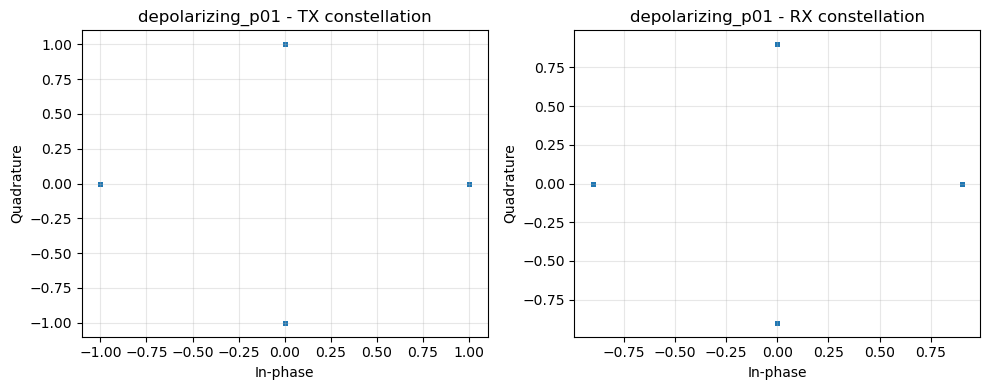

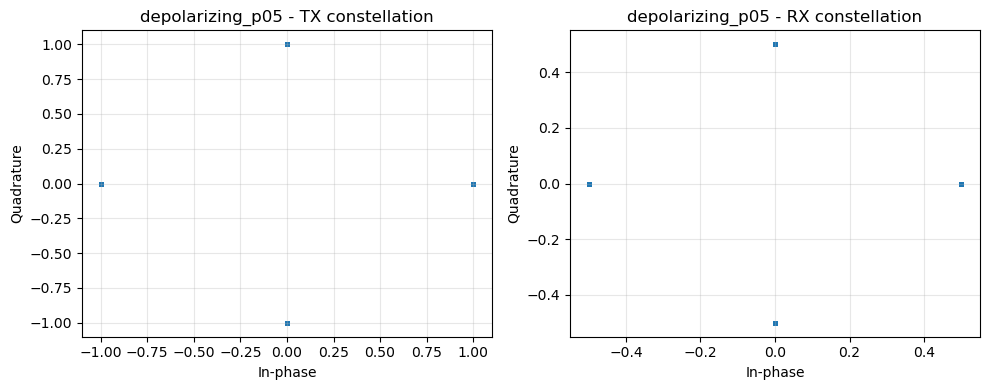

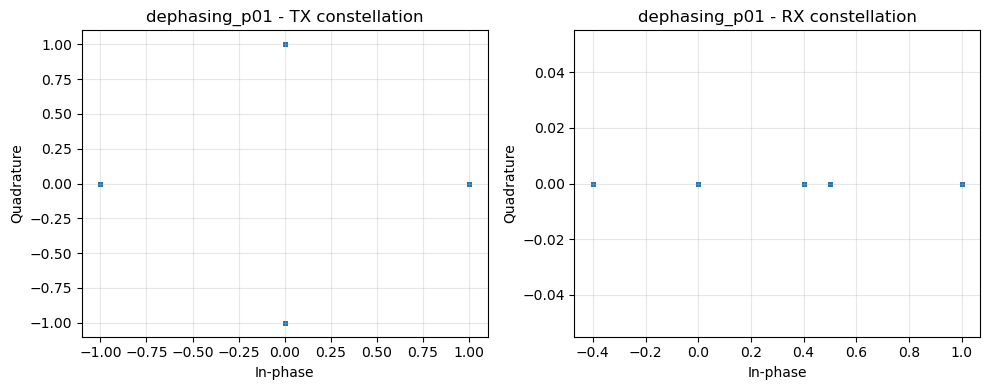

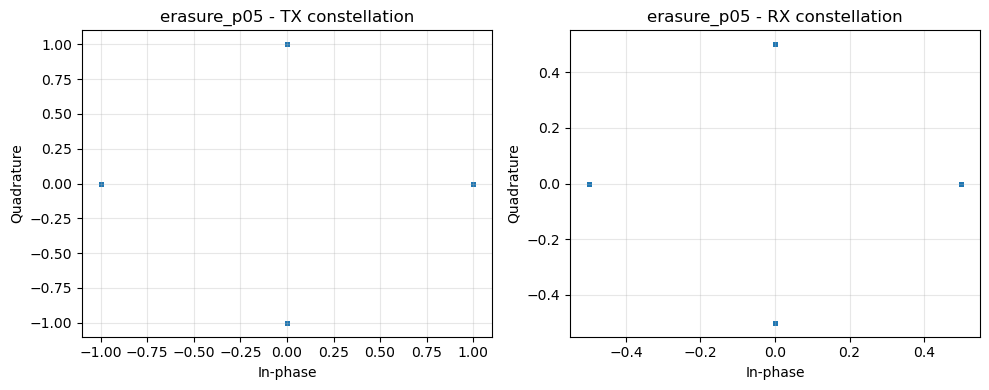

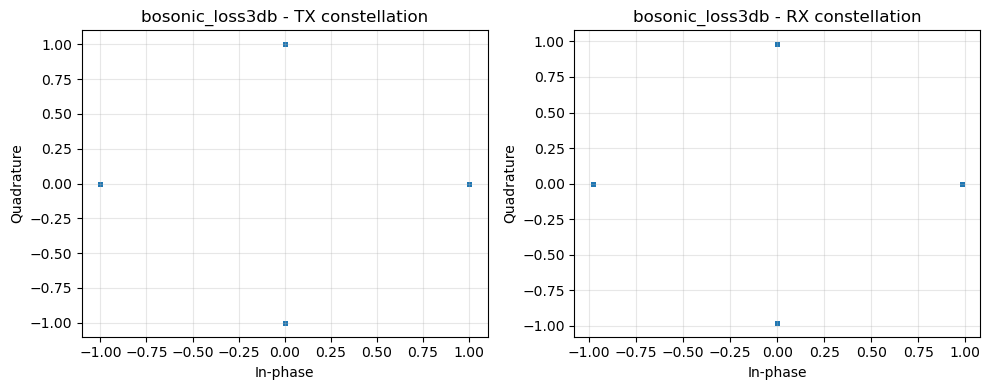

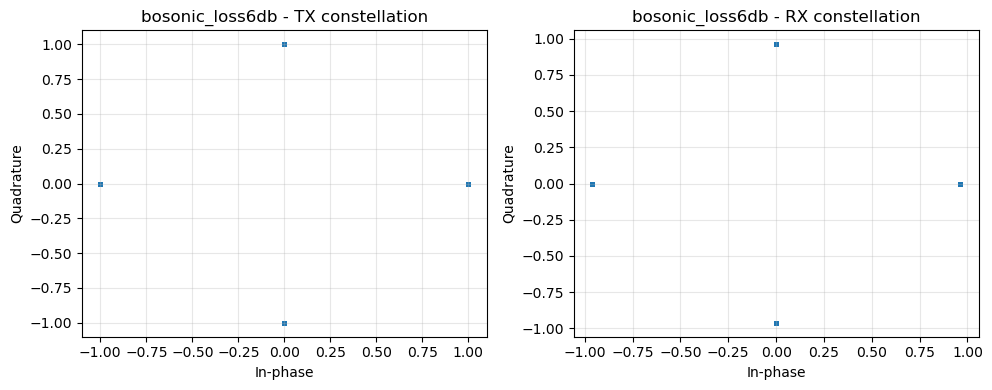

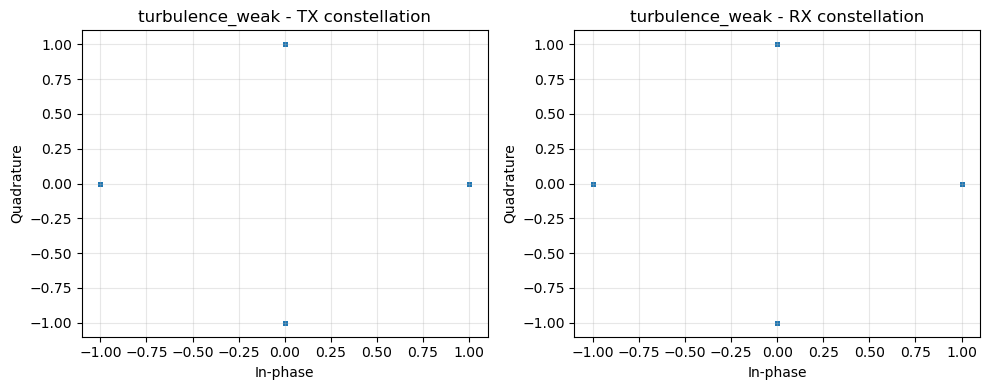

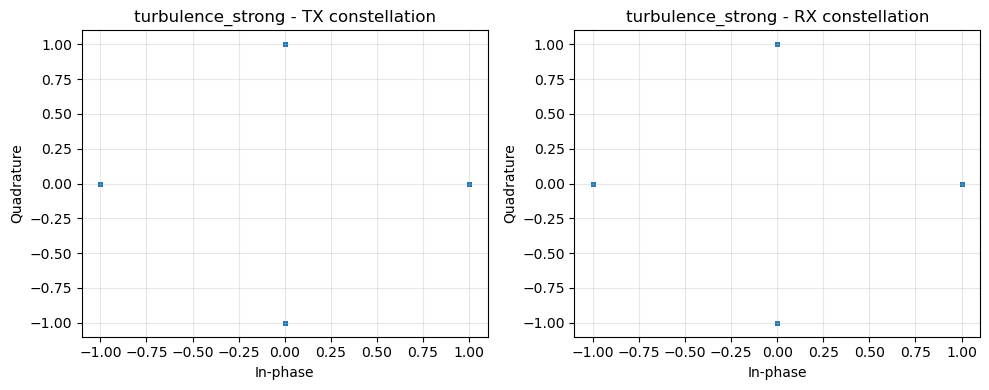

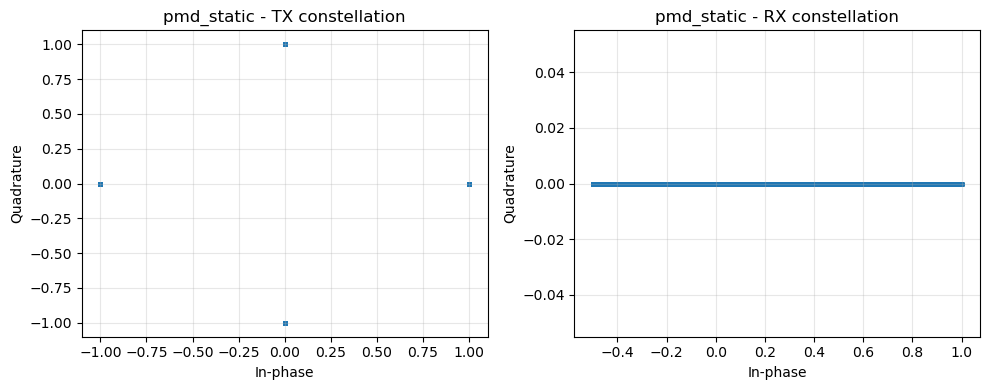

[pmd_static          ] BER=5.0650e-01, SER=7.6650e-01
[depolarizing_p01    ] BER=7.5675e-01, SER=7.5675e-01
[depolarizing_p05    ] BER=7.5675e-01, SER=7.5675e-01
[dephasing_p01       ] BER=7.5675e-01, SER=7.5675e-01
[erasure_p05         ] BER=7.5675e-01, SER=7.5675e-01
[bosonic_loss3db     ] BER=7.5675e-01, SER=7.5675e-01
[bosonic_loss6db     ] BER=7.5675e-01, SER=7.5675e-01
[turbulence_weak     ] BER=7.5675e-01, SER=7.5675e-01
[turbulence_strong   ] BER=7.5675e-01, SER=7.5675e-01
Saved summary to c:\Users\z642291\Downloads\workspace\quantum-comm-sim\notebooks\..\results\data\quantum_channel_baseline_summary.txt


In [10]:

# Run sweep and visualize a few representative channels
channel_configs = get_channel_configs()

summary = []

for name, ch_fn in channel_configs.items():
    ch = ch_fn()
    ber, ser, tx_sym, rx_sym = run_simulation(ch, num_symbols=4000, seed=123)
    summary.append((name, ber, ser))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plot_constellation(axes[0], tx_sym, f"{name} - TX constellation")
    plot_constellation(axes[1], rx_sym, f"{name} - RX constellation")
    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f"constellation_{name}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

# Sort and store summary
summary = sorted(summary, key=lambda x: x[1])
for name, ber, ser in summary:
    print(f"[{name:20s}] BER={ber:.4e}, SER={ser:.4e}")

summary_path = os.path.join(DATA_DIR, "quantum_channel_baseline_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("# name, BER, SER")
    for name, ber, ser in summary:
        f.write(f"{name}, {ber:.6e}, {ser:.6e}")

print(f"Saved summary to {summary_path}")